# **Geographic Disparities in Hospital Financial Performance Under Medicare Value-Based Purchasing (FY2021)**

## Study objective
This notebook examines whether hospital financial performance in FY2021 is associated with:

Medicare VBP adjustment factors, and
county-level social vulnerability (SVI).
The analysis is restricted to short-term hospitals (STH) with a valid FY2021 VBP adjustment factor, since the project is specifically about VBP hospitals.

## Data sources
We combine four sources:

CMS HCRIS (provider cost report data)

CMS FY2021 Hospital VBP adjustment factor file

County crosswalk (for county-to-FIPS mapping)

CDC/ATSDR SVI 2020 county file (RPL_THEMES)

In [1]:
# ==========================================
#  Configuration and imports 
# ==========================================
import os
import re
import csv
import time
import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

@dataclass
class Config:
    BASE: str = "https://data.cms.gov/data-api/v1"
    HCRIS_UUID: str = "eb8ff7ca-efdb-44cb-8b29-fed71d520afb"
    PAGE_SIZE: int = 5000
    SLEEP_S: float = 0.2
    TIMEOUT_S: int = 60
    MAX_RETRIES: int = 5
    BACKOFF_BASE_S: float = 1.5

    VBP_FILE_2021: str = r"TABLE 16B - ACTUAL HOSPITAL VBP ADJUSTMENT FACTORS FOR FY 2021.xlsx"
    SVI_FILE_2020: str = r"SVI_2020_US_county.csv"
    COUNTY_XWALK: str = r"national_county.txt"

    OUTDIR: str = "data_out"
    FIGDIR: str = "figures"
    LOGDIR: str = "logs"
    CACHEDIR: str = "cache"

    OUT_FULL_HCRIS: str = "hospital_provider_cost_report_full.csv"
    OUT_FINAL: str = "hcris_fy2021_sth_margin_vbp_svi_final.csv"
    OUT_QA_JSON: str = "qa_checks.json"

    FY_START: pd.Timestamp = pd.Timestamp("2020-10-01")
    FY_END: pd.Timestamp = pd.Timestamp("2021-09-30")
    STAY_STH_ONLY: bool = True
    RANDOM_SEED: int = 42

cfg = Config()
for d in [cfg.OUTDIR, cfg.FIGDIR, cfg.LOGDIR, cfg.CACHEDIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

np.random.seed(cfg.RANDOM_SEED)
session = requests.Session()

## Utility functions
These helpers keep the notebook cleaner and avoid repeating the same logic.



In [2]:
# =========================
# 2) Utility functions
# =========================
session = requests.Session()

def audit_df(df, name, top_missing=10):
    print(f"\n{'='*90}\n{name}\n{'='*90}")
    print(f"Shape: {df.shape}")
    miss = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
    print("Top missing (%):")
    print(miss.head(top_missing))

def clean_ccn(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(6)

def norm_county(s):
    if pd.isna(s):
        return ""
    s = str(s).upper().strip()
    s = re.sub(r"\bE\.\b", "EAST", s)
    s = re.sub(r"\bW\.\b", "WEST", s)
    s = re.sub(r"\bN\.\b", "NORTH", s)
    s = re.sub(r"\bS\.\b", "SOUTH", s)
    s = s.replace("&", " AND ")
    s = re.sub(r"[-/]", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    for suf in [" COUNTY"," PARISH"," BOROUGH"," CENSUS AREA"," MUNICIPALITY"," CITY AND BOROUGH"," CITY"]:
        if s.endswith(suf):
            s = s[:-len(suf)].strip()
    return s

def sniff_delimiter(path, sample_bytes=4096):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        sample = f.read(sample_bytes)
    try:
        return csv.Sniffer().sniff(sample, delimiters=["|", "\t", ","]).delimiter
    except Exception:
        return None

def read_county_crosswalk(path):
    delim = sniff_delimiter(path)
    candidates = ([delim] if delim else []) + ["|", "\t", ","]
    for sep in candidates:
        try:
            tmp = pd.read_csv(path, sep=sep, header=None, dtype=str, engine="python")
            if tmp.shape[1] >= 5:
                tmp = tmp.iloc[:, :5].copy()
                tmp.columns = ["state_abbr", "state_fips", "county_fips", "county_name", "class_code"]
                return tmp
        except Exception:
            continue
    raise ValueError("Could not parse county crosswalk file.")

def get_json(url, params=None, timeout=cfg.TIMEOUT_S):
    last_err = None
    for k in range(cfg.MAX_RETRIES):
        try:
            r = session.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            time.sleep((cfg.BACKOFF_BASE_S ** k) + np.random.uniform(0, 0.25))
    raise RuntimeError(f"Request failed: {url}") from last_err

def fetch_all_cms_rows(dataset_uuid):
    data_url = f"{cfg.BASE}/dataset/{dataset_uuid}/data"
    stats_url = f"{cfg.BASE}/dataset/{dataset_uuid}/data/stats"
    stats_json = get_json(stats_url)
    print("CMS rows (reported):", stats_json.get("found_rows", stats_json))

    rows, offset = [], 0
    while True:
        chunk = get_json(data_url, params={"size": cfg.PAGE_SIZE, "offset": offset})
        if not chunk:
            break
        rows.extend(chunk)
        offset += cfg.PAGE_SIZE
        time.sleep(cfg.SLEEP_S)
    return pd.DataFrame(rows)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled if pooled > 0 else np.nan

## Data extraction and caching
Load HCRIS from cache if available; otherwise pull from CMS API and save cache.



In [3]:
# =========================
# 3) Data extraction & caching
# =========================
cache_path = os.path.join(cfg.CACHEDIR, "hcris_raw.parquet")

if os.path.exists(cache_path):
    hcris = pd.read_parquet(cache_path)
else:
    hcris = fetch_all_cms_rows(cfg.HCRIS_UUID)
    hcris.to_parquet(cache_path, index=False)

hcris.to_csv(os.path.join(cfg.OUTDIR, cfg.OUT_FULL_HCRIS), index=False)
audit_df(hcris, "HCRIS raw")


HCRIS raw
Shape: (6053, 117)
Top missing (%):
rpt_rec_num             0.0
Provider CCN            0.0
Hospital Name           0.0
Street Address          0.0
City                    0.0
State Code              0.0
Zip Code                0.0
County                  0.0
Medicare CBSA Number    0.0
Rural Versus Urban      0.0
dtype: float64


## Data cleaning and FY2021 sample construction
Key restrictions:

1. FY2021 reports only: Fiscal Year End Date between 2020-10-01 and 2021-09-30
2. STH hospitals only
3. valid net patient revenue and operating expense fields
4. one report per hospital (latest within FY window)

In [4]:
# =========================
# 4) Data cleaning (FY2021 + STH)
# =========================
needed_cols = [
    "rpt_rec_num","Provider CCN","Hospital Name","City","State Code","County",
    "Medicare CBSA Number","Rural Versus Urban","CCN Facility Type",
    "Provider Type","Type of Control",
    "Fiscal Year Begin Date","Fiscal Year End Date",
    "Number of Beds","Total Patient Revenue","Net Patient Revenue",
    "Less Total Operating Expense","Net Income",
]
missing_cols = [c for c in needed_cols if c not in hcris.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df = hcris[needed_cols].copy()
df["Fiscal Year End Date"] = pd.to_datetime(df["Fiscal Year End Date"], errors="coerce")
df = df[df["Fiscal Year End Date"].between(cfg.FY_START, cfg.FY_END)].copy()

for c in ["Net Patient Revenue","Less Total Operating Expense","Net Income","Total Patient Revenue","Number of Beds"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Net Patient Revenue","Less Total Operating Expense"])
df = df[df["Net Patient Revenue"] > 0].copy()

# Main outcome: operating margin proxy
df["operating_margin"] = (df["Net Patient Revenue"] - df["Less Total Operating Expense"]) / df["Net Patient Revenue"]
df = df[df["operating_margin"].between(-1, 1)].copy()

if cfg.STAY_STH_ONLY:
    df = df[df["CCN Facility Type"].astype(str).str.strip().eq("STH")].copy()

df["ccn"] = clean_ccn(df["Provider CCN"])
df["rpt_rec_num_num"] = pd.to_numeric(df["rpt_rec_num"], errors="coerce")

df = df.sort_values(["ccn","Fiscal Year End Date","rpt_rec_num_num"], ascending=[True,False,False])
df = df.drop_duplicates(subset=["ccn"], keep="first").copy()

print("Rows after FY2021 + STH + dedupe:", len(df))

Rows after FY2021 + STH + dedupe: 555


## Merge VBP data
We merge FY2021 VBP adjustment factors by CCN and keep hospitals with non-missing VBP values.
This restriction is intentional because the research question is specifically about VBP hospitals.

In [5]:
# =========================
# 5) Merge VBP data
# =========================
vbp_raw = pd.read_excel(cfg.VBP_FILE_2021, header=1, dtype=str)

col_ccn = next((c for c in vbp_raw.columns if ("Certification Number" in str(c)) or ("CCN" in str(c))), None)
col_factor = next((c for c in vbp_raw.columns if ("Adjustment Factor" in str(c)) and ("2021" in str(c))), None)
if col_ccn is None or col_factor is None:
    raise ValueError("Could not detect VBP CCN/factor columns.")

vbp = vbp_raw[[col_ccn, col_factor]].rename(columns={col_ccn: "ccn", col_factor: "vbp_adjustment_factor_fy2021"}).copy()
vbp["ccn"] = clean_ccn(vbp["ccn"])
vbp["vbp_adjustment_factor_fy2021"] = pd.to_numeric(vbp["vbp_adjustment_factor_fy2021"], errors="coerce")
vbp = vbp.dropna(subset=["ccn","vbp_adjustment_factor_fy2021"]).drop_duplicates(subset=["ccn"])

df_vbp = df.merge(vbp, on="ccn", how="left")
vbp_match_rate = 1 - df_vbp["vbp_adjustment_factor_fy2021"].isna().mean()

# Keep VBP-only sample
df_vbp = df_vbp.dropna(subset=["vbp_adjustment_factor_fy2021"]).copy()
print(f"VBP match rate (before restriction): {vbp_match_rate:.2%}")
print(f"Rows after VBP restriction: {len(df_vbp)}")

VBP match rate (before restriction): 85.77%
Rows after VBP restriction: 476


## Merge county FIPS and SVI data
We standardize county names, map county+state to FIPS, then merge SVI (RPL_THEMES).

In [6]:
# =========================
# 6) Merge county FIPS + SVI
# =========================
xwalk = read_county_crosswalk(cfg.COUNTY_XWALK).copy()
xwalk["state_abbr"] = xwalk["state_abbr"].astype(str).str.strip().str.upper()
xwalk["state_fips"] = xwalk["state_fips"].astype(str).str.strip().str.zfill(2)
xwalk["county_fips"] = xwalk["county_fips"].astype(str).str.strip().str.zfill(3)
xwalk["county_key"] = xwalk["county_name"].map(norm_county)
xwalk["FIPS"] = xwalk["state_fips"] + xwalk["county_fips"]
xwalk = xwalk.drop_duplicates(subset=["state_abbr","county_key"], keep="first")

df_vbp["State_clean"] = df_vbp["State Code"].astype(str).str.strip().str.upper()
df_vbp["County"] = df_vbp["County"].astype("string").str.strip().mask(lambda s: s.eq(""), pd.NA)
df_vbp["County"] = df_vbp["County"].replace({
    "DC": "DISTRICT OF COLUMBIA",
    "DE SOTO": "DESOTO",
    "LA SALLE": "LASALLE",
    "E. BATON ROUGE PARISH": "EAST BATON ROUGE PARISH",
    "DE WITT": "DEWITT",
})
df_vbp["County_key"] = df_vbp["County"].map(norm_county)

df_main = df_vbp.merge(
    xwalk[["state_abbr","county_key","FIPS"]],
    left_on=["State_clean","County_key"],
    right_on=["state_abbr","county_key"],
    how="left"
)

df_main["FIPS"] = df_main["FIPS"].astype("string").str.strip()
df_main["FIPS"] = df_main["FIPS"].where(df_main["FIPS"].str.fullmatch(r"\d{5}"), pd.NA)

svi = pd.read_csv(cfg.SVI_FILE_2020, dtype=str)
if not {"FIPS","RPL_THEMES"}.issubset(svi.columns):
    raise ValueError("SVI file must contain FIPS and RPL_THEMES.")
svi = svi[["FIPS","RPL_THEMES"]].copy()
svi["FIPS"] = svi["FIPS"].astype("string").str.strip().str.zfill(5)
svi["RPL_THEMES"] = pd.to_numeric(svi["RPL_THEMES"], errors="coerce")
svi.loc[svi["RPL_THEMES"] < 0, "RPL_THEMES"] = np.nan
svi = svi.drop_duplicates(subset=["FIPS"], keep="first")

df_main = df_main.merge(svi, on="FIPS", how="left")
df_main["SVI_missing"] = df_main["RPL_THEMES"].isna().astype(int)

# Alternative margin only for sensitivity section
df_main["margin_net_income"] = df_main["Net Income"] / df_main["Total Patient Revenue"]

df_main.to_csv(os.path.join(cfg.OUTDIR, cfg.OUT_FINAL), index=False)
print("Saved final analytic file.")

Saved final analytic file.


## Data quality checks
Here we report match rates and basic QA counts.

In [7]:
# =========================
# 7) Data quality checks
# =========================
qa = {
    "rows_hcris_raw": int(hcris.shape[0]),
    "rows_after_fy2021_sth_dedupe": int(df.shape[0]),
    "rows_after_vbp_restriction": int(df_vbp.shape[0]),
    "rows_final_after_svi_merge": int(df_main.shape[0]),
    "vbp_match_rate_before_restriction": float(round(vbp_match_rate, 6)),
    "fips_match_rate": float(round(1 - df_main["FIPS"].isna().mean(), 6)),
    "svi_non_missing_rate": float(round(1 - df_main["RPL_THEMES"].isna().mean(), 6)),
    "svi_missing_pct": float(round(df_main["RPL_THEMES"].isna().mean() * 100, 2)),
}

with open(os.path.join(cfg.LOGDIR, cfg.OUT_QA_JSON), "w") as f:
    json.dump(qa, f, indent=2)

print(json.dumps(qa, indent=2))
print("\nInterpretation: FIPS and SVI match rates are important because they affect county-level inference.")

{
  "rows_hcris_raw": 6053,
  "rows_after_fy2021_sth_dedupe": 555,
  "rows_after_vbp_restriction": 476,
  "rows_final_after_svi_merge": 476,
  "vbp_match_rate_before_restriction": 0.857658,
  "fips_match_rate": 0.915966,
  "svi_non_missing_rate": 0.915966,
  "svi_missing_pct": 8.4
}

Interpretation: FIPS and SVI match rates are important because they affect county-level inference.


## Exploratory data analysis (EDA)
This section gives a quick view of distributions, pairwise patterns, and grouped summaries.


=== Descriptive Statistics ===
       operating_margin  vbp_adjustment_factor_fy2021  RPL_THEMES  Number of Beds
count          476.0000                      476.0000    436.0000        476.0000
mean            -0.0290                        1.0014      0.6388        222.2395
std              0.1772                        0.0071      0.2443        218.6979
min             -0.9260                        0.9856      0.0261         25.0000
25%             -0.1103                        0.9960      0.4634         75.0000
50%             -0.0249                        1.0008      0.6989        157.0000
75%              0.0702                        1.0056      0.8239        289.2500
max              0.5660                        1.0394      0.9990       1600.0000

=== Correlation Matrix ===
                              operating_margin  vbp_adjustment_factor_fy2021  RPL_THEMES  Number of Beds
operating_margin                        1.0000                        0.0695      0.0216         

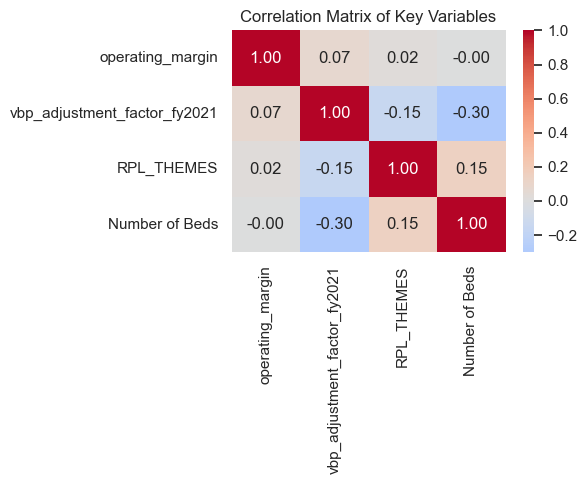

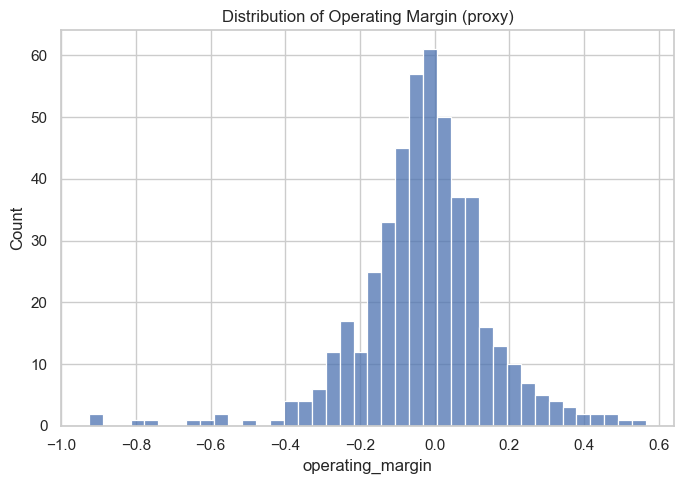

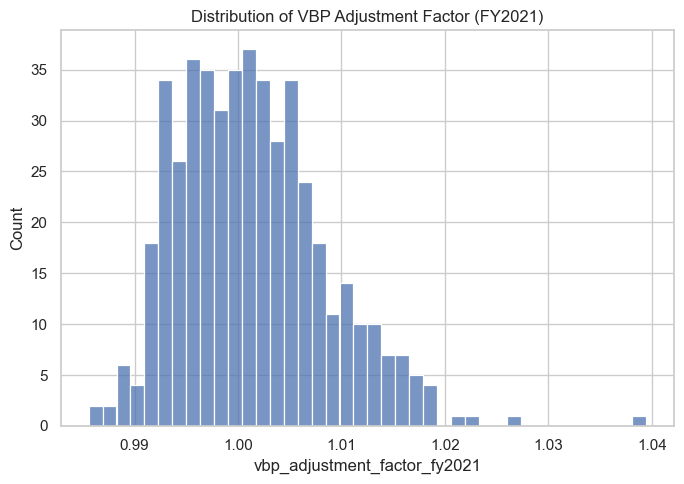

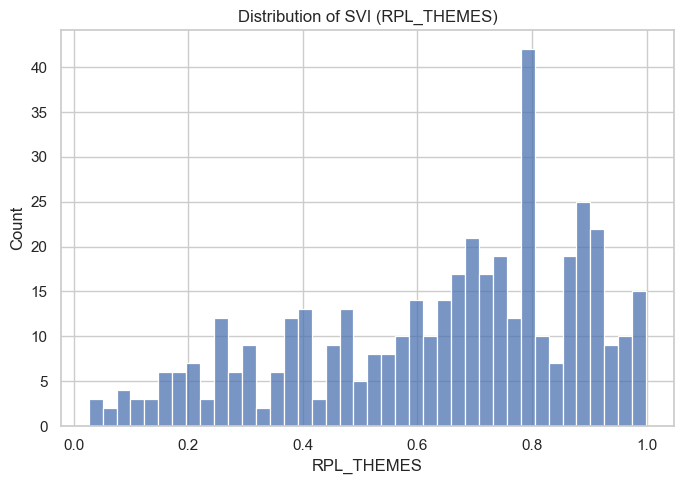

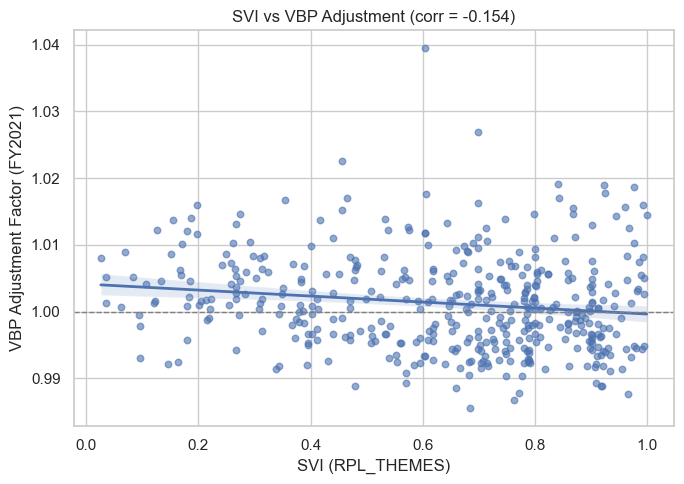

Interpretation: Pearson direction looks negative and magnitude is 0.154.

=== Rural vs Urban Summary ===
                   operating_margin               vbp_adjustment_factor_fy2021              
                               mean  median count                         mean  median count
Rural Versus Urban                                                                          
R                           -0.0531 -0.0484   230                       1.0012  1.0005   230
U                           -0.0064 -0.0073   246                       1.0016  1.0010   246

=== VBP by SVI Quartile Summary ===
                mean  median  count
SVI_quartile                       
Q1            1.0032  1.0022    109
Q2            1.0016  1.0015    115
Q3            0.9994  0.9987    103
Q4            1.0008  0.9992    109


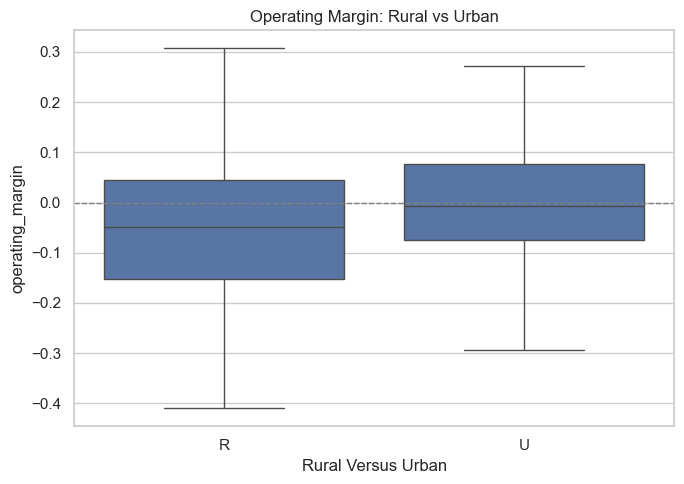

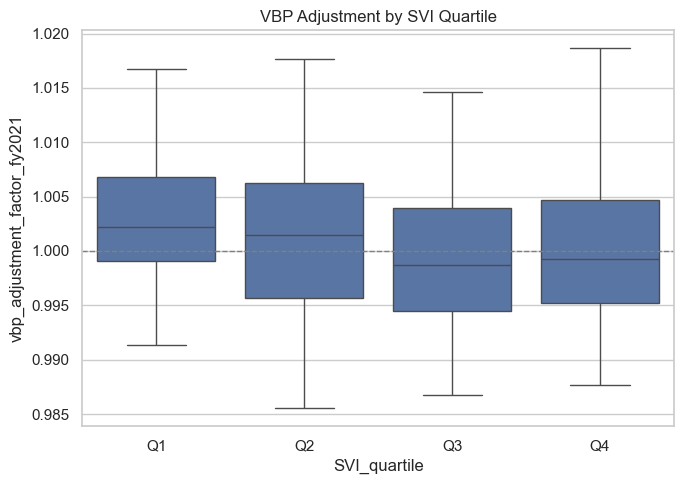

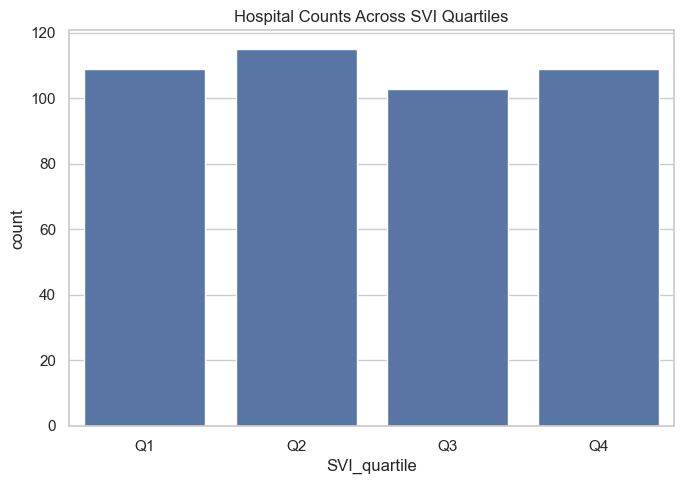

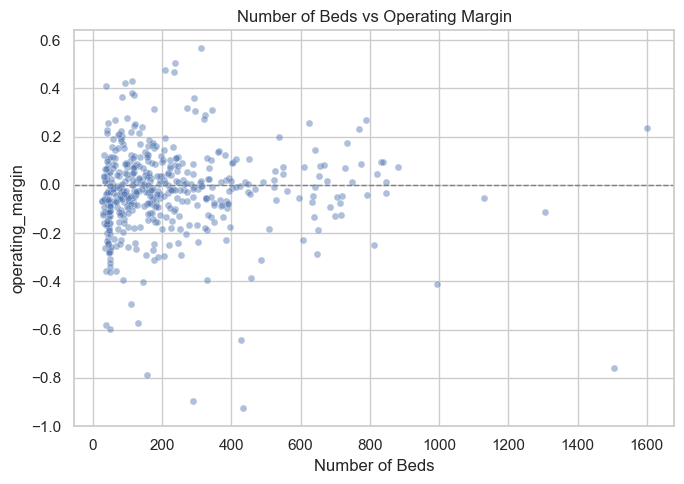

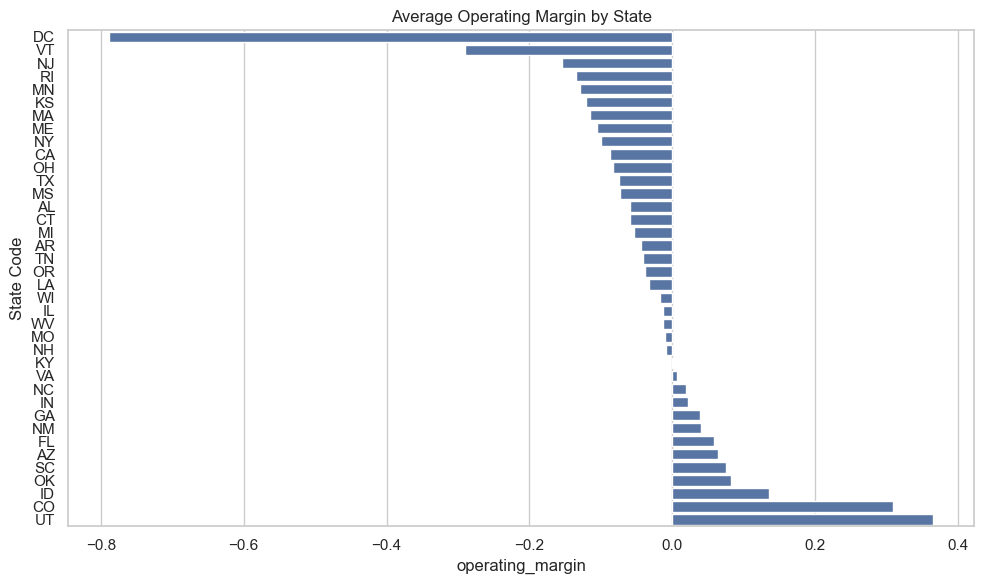


Top Margin Hospitals
                            Hospital Name  operating_margin
5             EAST ALABAMA MEDICAL CENTER          0.566016
389         PRISMA HEALTH TUOMEY HOSPITAL          0.506668
124              ST. LUCIE MEDICAL CENTER          0.475446
152  EASTERN IDAHO REGIONAL MEDICAL CENTE          0.466428
16   SOUTH BALDWIN REGIONAL MEDICAL CENTE          0.430377

Lowest Margin Hospitals
                            Hospital Name  operating_margin
415         TCHD D/B/A JPS HEALTH NETWORK         -0.925984
413  UNIVERSITY MEDICAL CENTER OF EL PASO         -0.894548
81    NOT-FOR-PROFIT HOSPITAL CORPORATION         -0.788118
89                       JACKSON MEMORIAL         -0.757911
230                 BOSTON MEDICAL CENTER         -0.642547


In [8]:
# Numeric coercion
for c in ["operating_margin","vbp_adjustment_factor_fy2021","RPL_THEMES","Number of Beds","margin_net_income"]:
    if c in df_main.columns:
        df_main[c] = pd.to_numeric(df_main[c], errors="coerce")

num_cols = [c for c in ["operating_margin","vbp_adjustment_factor_fy2021","RPL_THEMES","Number of Beds"] if c in df_main.columns]

print("\n=== Descriptive Statistics ===")
print(df_main[num_cols].describe().round(4))

corr_matrix = df_main[num_cols].corr()
print("\n=== Correlation Matrix ===")
print(corr_matrix.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

# Histograms
hist_specs = [
    ("operating_margin", "Distribution of Operating Margin (proxy)"),
    ("vbp_adjustment_factor_fy2021", "Distribution of VBP Adjustment Factor (FY2021)"),
    ("RPL_THEMES", "Distribution of SVI (RPL_THEMES)")
]
for col, title in hist_specs:
    if col in df_main.columns:
        x = df_main[col].dropna()
        if len(x) == 0:
            continue
        plt.figure(figsize=(7, 5))
        sns.histplot(x, bins=40, kde=False)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# SVI vs VBP
req = ["RPL_THEMES","vbp_adjustment_factor_fy2021"]
if all(c in df_main.columns for c in req):
    df_plot = df_main.dropna(subset=req).copy()
    if len(df_plot) > 1:
        r = np.corrcoef(df_plot["RPL_THEMES"], df_plot["vbp_adjustment_factor_fy2021"])[0, 1]
        plt.figure(figsize=(7, 5))
        sns.regplot(
            x="RPL_THEMES", y="vbp_adjustment_factor_fy2021", data=df_plot,
            scatter_kws={"alpha":0.6, "s":22}, line_kws={"lw":2}
        )
        plt.axhline(1.0, linestyle="--", color="gray", linewidth=1)
        plt.title(f"SVI vs VBP Adjustment (corr = {r:.3f})")
        plt.xlabel("SVI (RPL_THEMES)")
        plt.ylabel("VBP Adjustment Factor (FY2021)")
        plt.tight_layout()
        plt.show()
        print(f"Interpretation: Pearson direction looks {'positive' if r>0 else 'negative'} and magnitude is {abs(r):.3f}.")

# Group summaries
if "Rural Versus Urban" in df_main.columns:
    ru_summary = (
        df_main.groupby("Rural Versus Urban")[["operating_margin","vbp_adjustment_factor_fy2021"]]
        .agg(["mean","median","count"])
        .round(4)
    )
    print("\n=== Rural vs Urban Summary ===")
    print(ru_summary)

if all(c in df_main.columns for c in ["RPL_THEMES","vbp_adjustment_factor_fy2021"]):
    df_anova = df_main.dropna(subset=["RPL_THEMES","vbp_adjustment_factor_fy2021"]).copy()
    if len(df_anova) > 0:
        df_anova["SVI_quartile"] = pd.qcut(
            df_anova["RPL_THEMES"], q=4, labels=["Q1","Q2","Q3","Q4"], duplicates="drop"
        )
        quartile_summary = (
            df_anova.groupby("SVI_quartile", observed=True)["vbp_adjustment_factor_fy2021"]
            .agg(["mean","median","count"]).round(4)
        )
        print("\n=== VBP by SVI Quartile Summary ===")
        print(quartile_summary)

        if "Rural Versus Urban" in df_main.columns:
            plt.figure(figsize=(7,5))
            sns.boxplot(x="Rural Versus Urban", y="operating_margin", data=df_main, order=["R","U"], showfliers=False)
            plt.axhline(0, linestyle="--", color="gray", linewidth=1)
            plt.title("Operating Margin: Rural vs Urban")
            plt.tight_layout()
            plt.show()

        plt.figure(figsize=(7,5))
        sns.boxplot(x="SVI_quartile", y="vbp_adjustment_factor_fy2021", data=df_anova, order=["Q1","Q2","Q3","Q4"], showfliers=False)
        plt.axhline(1.0, linestyle="--", color="gray", linewidth=1)
        plt.title("VBP Adjustment by SVI Quartile")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))
        sns.countplot(x="SVI_quartile", data=df_anova, order=["Q1","Q2","Q3","Q4"])
        plt.title("Hospital Counts Across SVI Quartiles")
        plt.tight_layout()
        plt.show()

# Beds vs margin
if all(c in df_main.columns for c in ["Number of Beds","operating_margin"]):
    df_scatter = df_main.dropna(subset=["Number of Beds","operating_margin"])
    if len(df_scatter) > 0:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x="Number of Beds", y="operating_margin", data=df_scatter, alpha=0.45, s=25)
        plt.axhline(0, linestyle="--", color="gray", linewidth=1)
        plt.title("Number of Beds vs Operating Margin")
        plt.tight_layout()
        plt.show()

state_summary = df_main.groupby("State Code")["operating_margin"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=state_summary.sort_values("operating_margin"), x="operating_margin", y="State Code")
plt.title("Average Operating Margin by State")
plt.tight_layout()
plt.show()

top_outliers = df_main.nlargest(5, "operating_margin")[["Hospital Name","operating_margin"]]
bottom_outliers = df_main.nsmallest(5, "operating_margin")[["Hospital Name","operating_margin"]]
print("\nTop Margin Hospitals")
print(top_outliers)
print("\nLowest Margin Hospitals")
print(bottom_outliers)


# EDA Interpretation


## Descriptive Statistics
The average operating margin is slightly negative (-0.029), indicating that many hospitals operate near break-even or at a loss.  
The VBP adjustment factor is tightly centered around 1.0, suggesting only small financial adjustments.  
SVI shows wide variation, indicating meaningful differences in social vulnerability across counties.

---

## Correlation Matrix
Operating margin shows a very weak relationship with both VBP (0.07) and SVI (0.02), suggesting limited direct association.  
SVI and VBP have a weak negative correlation (-0.15), indicating that more vulnerable counties tend to receive slightly lower VBP adjustments.  
Number of beds has a moderate negative correlation with VBP (-0.30), suggesting larger hospitals may receive lower adjustments.

---

## Distribution of Operating Margin
Operating margin is centered slightly below zero, with a left-skewed distribution and several negative outliers.  
This indicates that a substantial number of hospitals experience financial losses, while fewer achieve high positive margins.

---

## Distribution of VBP Adjustment Factor
The VBP adjustment factor is narrowly distributed around 1.0, indicating that most hospitals receive only small payment adjustments.  
Extreme values are rare, suggesting limited variation in VBP incentives.

---

## Distribution of Social Vulnerability Index (SVI)
SVI values are widely distributed across the full range, indicating substantial variation in social vulnerability across counties.  
This variability supports its use as a meaningful explanatory variable in the analysis.

---

## SVI vs VBP Relationship
There is a weak negative relationship between SVI and VBP adjustment (corr ≈ -0.15).  
This suggests that hospitals in more vulnerable counties may receive slightly lower VBP adjustments, though the relationship is weak.

---

## Rural vs Urban Comparison
Rural hospitals have a lower average operating margin compared to urban hospitals.  
This suggests potential financial disadvantage for rural hospitals, which will be formally tested in later analysis.

---

## VBP by SVI Quartiles
Mean VBP adjustment factors vary slightly across SVI quartiles, with lower values observed in higher vulnerability groups.  
This suggests a potential relationship between social vulnerability and VBP adjustments, which will be tested using ANOVA.

---

## Hospital Counts Across SVI Quartiles
Hospitals are relatively evenly distributed across SVI quartiles, indicating balanced group sizes.  
This supports the validity of comparative statistical tests such as ANOVA.

---

## Number of Beds vs Operating Margin
There is no clear relationship between number of beds and operating margin.  
This suggests hospital size alone may not be a strong predictor of financial performance.

---

## State-Level Variation in Operating Margin
There is noticeable variation in average operating margin across states.  
This suggests that geographic or policy differences may influence hospital financial performance.

---

## Outliers (Top and Bottom Hospitals)
A small number of hospitals exhibit extremely high or low operating margins.  
These outliers may reflect unique operational conditions or reporting differences and should be interpreted cautiously.

# =============================================


# Hypothesis Formulation






### H1: Rural vs Urban – Operating Margin
H0: The mean operating margin of rural hospitals is equal to that of urban hospitals.  
H1: The mean operating margin of rural hospitals is different from that of urban hospitals.

---

### H2: Rural vs Urban – VBP Adjustment Factor
H0: The mean VBP adjustment factor of rural hospitals is equal to that of urban hospitals.  
H1: The mean VBP adjustment factor of rural hospitals is different from that of urban hospitals.

---

### H3: SVI Quartile vs Operating Margin
H0: The mean operating margin is equal across all SVI quartiles.  
H1: At least one SVI quartile has a different mean operating margin.

---

### H4: SVI Quartile vs VBP Adjustment Factor
H0: The mean VBP adjustment factor is equal across all SVI quartiles.  
H1: At least one SVI quartile has a different mean VBP adjustment factor.

---

### H5: Rural/Urban vs SVI Quartile (Association)
H0: Rural versus urban classification is independent of SVI quartile.  
H1: Rural versus urban classification is associated with SVI quartile.

---


### H6: SVI vs VBP Adjustment Factor
H0: There is no correlation between SVI and VBP adjustment factor (ρ = 0).  
H1: There is a correlation between SVI and VBP adjustment factor (ρ ≠ 0).

---

### H7: VBP Adjustment Factor vs Operating Margin
H0: There is no relationship between VBP adjustment factor and operating margin (β = 0).  
H1: There is a relationship between VBP adjustment factor and operating margin (β ≠ 0).

---

### H8: SVI vs Operating Margin
H0: There is no relationship between SVI and operating margin (β = 0).  
H1: There is a relationship between SVI and operating margin (β ≠ 0).

---

### H9: Number of Beds vs Operating Margin
H0: There is no relationship between number of beds and operating margin (β = 0).  
H1: There is a relationship between number of beds and operating margin (β ≠ 0).

---

### H10: SVI vs VBP (Controlled Regression Model)
H0: SVI has no effect on VBP adjustment factor after controlling for other variables (β = 0).  
H1: SVI has a significant effect on VBP adjustment factor after controlling for other variables (β ≠ 0).


# Assumption Checks


Overall assumption note:
- Independence is assumed because each observation represents a different hospital.
- Given the sample size, minor normality deviations are less likely to invalidate inference.
- Where assumptions are weakened, robust alternatives are used.

1) T-TEST ASSUMPTIONS (H1): Rural vs Urban - Operating Margin
Sample sizes -> Rural: 230, Urban: 246
Shapiro-Wilk (Rural): W=0.9689, p=6.19241e-05
Rural group: normality appears violated (p < 0.05).
Shapiro-Wilk (Urban): W=0.8980, p=7.44558e-12
Urban group: normality appears violated (p < 0.05).
Levene's test: stat=0.0034, p=0.953831
Equal variance assumption appears satisfied (p >= 0.05).
Method decision: standard equal-variance methods are acceptable, though Welch remains conservative.


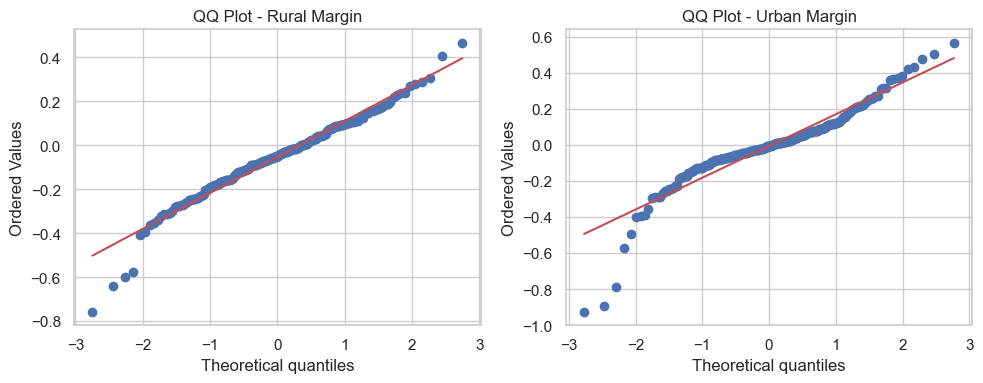


2) T-TEST ASSUMPTIONS (H2): Rural vs Urban - VBP Adjustment Factor
Sample sizes -> Rural: 230, Urban: 246
Shapiro-Wilk (Rural): W=0.9679, p=4.53783e-05
Rural group: normality appears violated (p < 0.05).
Shapiro-Wilk (Urban): W=0.9443, p=4.54053e-08
Urban group: normality appears violated (p < 0.05).
Levene's test: stat=3.7317, p=0.0539856
Equal variance assumption appears satisfied (p >= 0.05).
Method decision: standard equal-variance methods are acceptable, though Welch remains conservative.


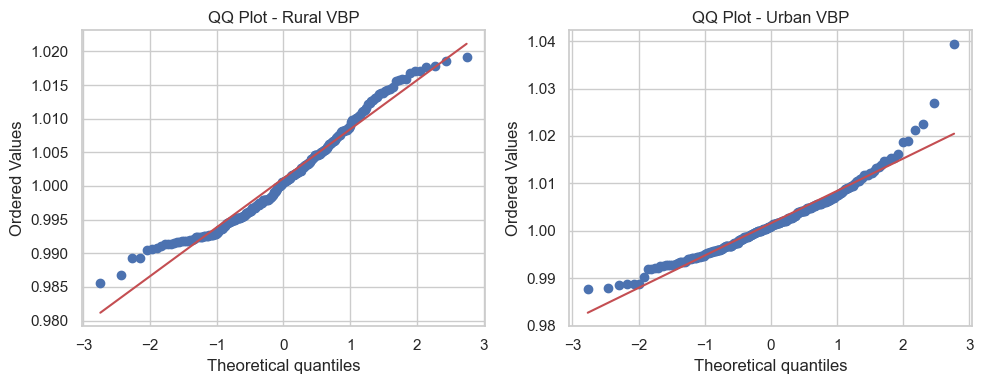


3) ANOVA ASSUMPTIONS (H3): SVI Quartile vs Operating Margin
Group sizes:
SVI_quartile
Q1    109
Q2    115
Q3    103
Q4    109
Name: count, dtype: int64
Shapiro-Wilk (Q1): W=0.9743, p=0.0329513
Q1 group: normality appears violated (p < 0.05).
Shapiro-Wilk (Q2): W=0.9370, p=3.95834e-05
Q2 group: normality appears violated (p < 0.05).
Shapiro-Wilk (Q3): W=0.9074, p=2.38676e-06
Q3 group: normality appears violated (p < 0.05).
Shapiro-Wilk (Q4): W=0.9163, p=3.90897e-06
Q4 group: normality appears violated (p < 0.05).
Levene's test across quartiles: stat=0.9486, p=0.416989
Equal variance assumption appears reasonably satisfied across quartiles.
Method decision: standard ANOVA is appropriate.


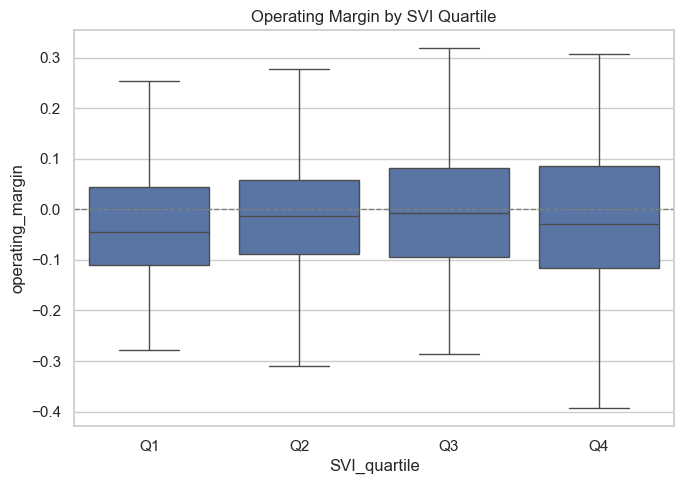


4) ANOVA ASSUMPTIONS (H4): SVI Quartile vs VBP Adjustment Factor
Group sizes:
SVI_quartile
Q1    109
Q2    115
Q3    103
Q4    109
Name: count, dtype: int64
Shapiro-Wilk (Q1): W=0.9836, p=0.202702
Q1 group: normality appears satisfied (p >= 0.05).
Shapiro-Wilk (Q2): W=0.9352, p=3.0347e-05
Q2 group: normality appears violated (p < 0.05).
Shapiro-Wilk (Q3): W=0.9789, p=0.0981851
Q3 group: normality appears satisfied (p >= 0.05).
Shapiro-Wilk (Q4): W=0.9389, p=8.235e-05
Q4 group: normality appears violated (p < 0.05).
Levene's test across quartiles: stat=2.5676, p=0.0539779
Equal variance assumption appears reasonably satisfied across quartiles.
Method decision: standard ANOVA is appropriate.


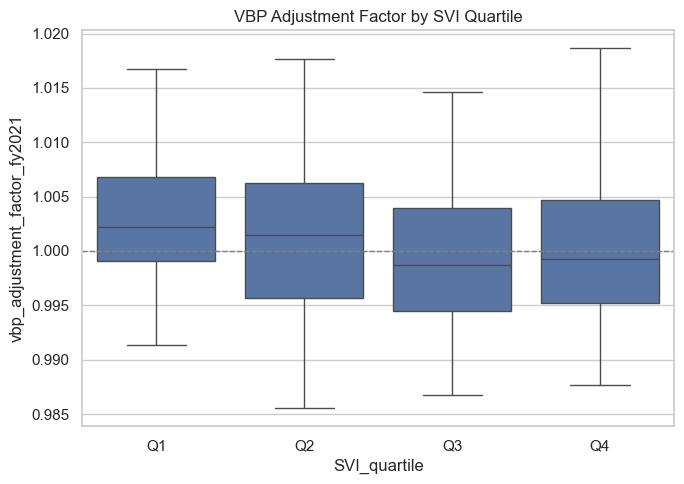


5) CHI-SQUARE ASSUMPTIONS (H5): Rural/Urban vs SVI Quartile
Contingency table:
SVI_quartile        Q1  Q2  Q3  Q4
Rural Versus Urban                
R                   47  56  49  67
U                   62  59  54  42
Minimum expected count: 51.2638
Expected count assumption is satisfied.
Method decision: chi-square test is appropriate.

6) CORRELATION ASSUMPTIONS (H6): SVI vs VBP Adjustment Factor


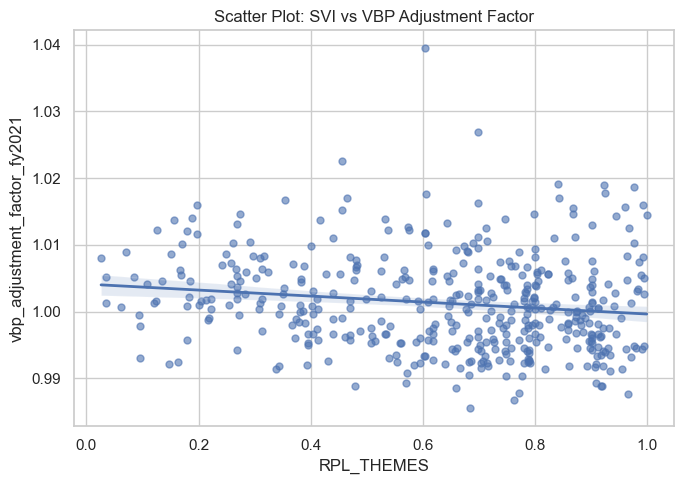

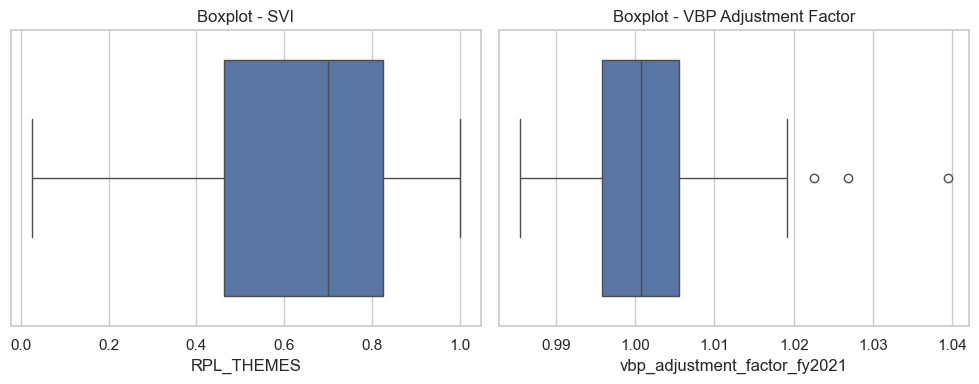


7) REGRESSION ASSUMPTIONS (H7-H10)


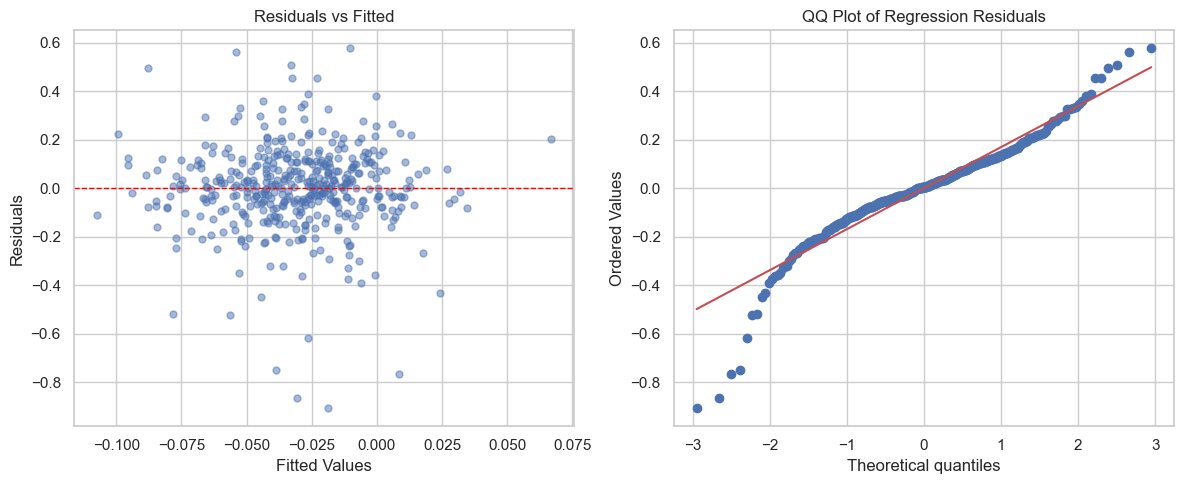

Shapiro-Wilk (residuals): W=0.9280, p=1.25677e-13
Residuals: normality appears violated (p < 0.05).

Variance Inflation Factor (VIF):
                    Variable        VIF
                       const 23664.1660
vbp_adjustment_factor_fy2021     1.1545
                  RPL_THEMES     1.0321
                    log_beds     1.1477

Breusch-Pagan test: LM=5.6824, p=0.128127; F=1.9015, p=0.128604
No strong evidence of heteroskedasticity (p >= 0.05).
Method decision: HC3 robust standard errors are still retained for robustness.


In [11]:


def section_title(title):
    print(f"\n{'='*90}\n{title}\n{'='*90}")

def normality_note(p, label):
    if p < 0.05:
        print(f"{label}: normality appears violated (p < 0.05).")
    else:
        print(f"{label}: normality appears satisfied (p >= 0.05).")

def variance_note(p):
    if p < 0.05:
        print("Equal variance assumption appears violated (p < 0.05).")
        print("Method decision: use Welch's t-test where appropriate.")
    else:
        print("Equal variance assumption appears satisfied (p >= 0.05).")
        print("Method decision: standard equal-variance methods are acceptable, though Welch remains conservative.")

def bp_note(p):
    if p < 0.05:
        print("Homoskedasticity appears violated (p < 0.05).")
        print("Method decision: use HC3 robust standard errors in regression.")
    else:
        print("No strong evidence of heteroskedasticity (p >= 0.05).")
        print("Method decision: HC3 robust standard errors are still retained for robustness.")

print("\nOverall assumption note:")
print("- Independence is assumed because each observation represents a different hospital.")
print("- Given the sample size, minor normality deviations are less likely to invalidate inference.")
print("- Where assumptions are weakened, robust alternatives are used.")

# ---------------------------------------------------
# 1) T-test assumptions: H1 Rural vs Urban - Operating Margin
# ---------------------------------------------------
section_title("1) T-TEST ASSUMPTIONS (H1): Rural vs Urban - Operating Margin")

rural_margin = df_main.loc[df_main["Rural Versus Urban"] == "R", "operating_margin"].dropna()
urban_margin = df_main.loc[df_main["Rural Versus Urban"] == "U", "operating_margin"].dropna()

print(f"Sample sizes -> Rural: {len(rural_margin)}, Urban: {len(urban_margin)}")

if len(rural_margin) > 2 and len(urban_margin) > 2:
    sh_rural = stats.shapiro(rural_margin)
    sh_urban = stats.shapiro(urban_margin)

    print(f"Shapiro-Wilk (Rural): W={sh_rural.statistic:.4f}, p={sh_rural.pvalue:.6g}")
    normality_note(sh_rural.pvalue, "Rural group")

    print(f"Shapiro-Wilk (Urban): W={sh_urban.statistic:.4f}, p={sh_urban.pvalue:.6g}")
    normality_note(sh_urban.pvalue, "Urban group")

    lev_stat, lev_p = stats.levene(rural_margin, urban_margin)
    print(f"Levene's test: stat={lev_stat:.4f}, p={lev_p:.6g}")
    variance_note(lev_p)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    stats.probplot(rural_margin, dist="norm", plot=ax[0])
    ax[0].set_title("QQ Plot - Rural Margin")

    stats.probplot(urban_margin, dist="norm", plot=ax[1])
    ax[1].set_title("QQ Plot - Urban Margin")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough observations to evaluate t-test assumptions.")

# ---------------------------------------------------
# 2) T-test assumptions: H2 Rural vs Urban - VBP
# ---------------------------------------------------
section_title("2) T-TEST ASSUMPTIONS (H2): Rural vs Urban - VBP Adjustment Factor")

rural_vbp = df_main.loc[df_main["Rural Versus Urban"] == "R", "vbp_adjustment_factor_fy2021"].dropna()
urban_vbp = df_main.loc[df_main["Rural Versus Urban"] == "U", "vbp_adjustment_factor_fy2021"].dropna()

print(f"Sample sizes -> Rural: {len(rural_vbp)}, Urban: {len(urban_vbp)}")

if len(rural_vbp) > 2 and len(urban_vbp) > 2:
    sh_rural = stats.shapiro(rural_vbp)
    sh_urban = stats.shapiro(urban_vbp)

    print(f"Shapiro-Wilk (Rural): W={sh_rural.statistic:.4f}, p={sh_rural.pvalue:.6g}")
    normality_note(sh_rural.pvalue, "Rural group")

    print(f"Shapiro-Wilk (Urban): W={sh_urban.statistic:.4f}, p={sh_urban.pvalue:.6g}")
    normality_note(sh_urban.pvalue, "Urban group")

    lev_stat, lev_p = stats.levene(rural_vbp, urban_vbp)
    print(f"Levene's test: stat={lev_stat:.4f}, p={lev_p:.6g}")
    variance_note(lev_p)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    stats.probplot(rural_vbp, dist="norm", plot=ax[0])
    ax[0].set_title("QQ Plot - Rural VBP")

    stats.probplot(urban_vbp, dist="norm", plot=ax[1])
    ax[1].set_title("QQ Plot - Urban VBP")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough observations to evaluate t-test assumptions.")

# ---------------------------------------------------
# 3) ANOVA assumptions: H3 SVI Quartile vs Operating Margin
# ---------------------------------------------------
section_title("3) ANOVA ASSUMPTIONS (H3): SVI Quartile vs Operating Margin")

df_anova_margin = df_main.dropna(subset=["RPL_THEMES", "operating_margin"]).copy()
df_anova_margin["SVI_quartile"] = pd.qcut(
    df_anova_margin["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

print("Group sizes:")
print(df_anova_margin["SVI_quartile"].value_counts().sort_index())

margin_groups = []
for q, g in df_anova_margin.groupby("SVI_quartile", observed=True):
    vals = g["operating_margin"].dropna()
    margin_groups.append(vals.values)

    if len(vals) > 2:
        sh = stats.shapiro(vals)
        print(f"Shapiro-Wilk ({q}): W={sh.statistic:.4f}, p={sh.pvalue:.6g}")
        normality_note(sh.pvalue, f"{q} group")

if len(margin_groups) >= 2 and all(len(g) > 1 for g in margin_groups):
    lev_stat, lev_p = stats.levene(*margin_groups)
    print(f"Levene's test across quartiles: stat={lev_stat:.4f}, p={lev_p:.6g}")

    if lev_p < 0.05:
        print("Equal variance assumption appears violated across quartiles.")
        print("Method decision: proceed with ANOVA cautiously and interpret post-hoc results carefully.")
    else:
        print("Equal variance assumption appears reasonably satisfied across quartiles.")
        print("Method decision: standard ANOVA is appropriate.")

    plt.figure(figsize=(7, 5))
    sns.boxplot(x="SVI_quartile", y="operating_margin", data=df_anova_margin, order=["Q1", "Q2", "Q3", "Q4"], showfliers=False)
    plt.axhline(0, linestyle="--", color="gray", linewidth=1)
    plt.title("Operating Margin by SVI Quartile")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to evaluate ANOVA assumptions for H3.")

# ---------------------------------------------------
# 4) ANOVA assumptions: H4 SVI Quartile vs VBP
# ---------------------------------------------------
section_title("4) ANOVA ASSUMPTIONS (H4): SVI Quartile vs VBP Adjustment Factor")

df_anova_vbp = df_main.dropna(subset=["RPL_THEMES", "vbp_adjustment_factor_fy2021"]).copy()
df_anova_vbp["SVI_quartile"] = pd.qcut(
    df_anova_vbp["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

print("Group sizes:")
print(df_anova_vbp["SVI_quartile"].value_counts().sort_index())

vbp_groups = []
for q, g in df_anova_vbp.groupby("SVI_quartile", observed=True):
    vals = g["vbp_adjustment_factor_fy2021"].dropna()
    vbp_groups.append(vals.values)

    if len(vals) > 2:
        sh = stats.shapiro(vals)
        print(f"Shapiro-Wilk ({q}): W={sh.statistic:.4f}, p={sh.pvalue:.6g}")
        normality_note(sh.pvalue, f"{q} group")

if len(vbp_groups) >= 2 and all(len(g) > 1 for g in vbp_groups):
    lev_stat, lev_p = stats.levene(*vbp_groups)
    print(f"Levene's test across quartiles: stat={lev_stat:.4f}, p={lev_p:.6g}")

    if lev_p < 0.05:
        print("Equal variance assumption appears violated across quartiles.")
        print("Method decision: proceed with ANOVA cautiously and interpret post-hoc results carefully.")
    else:
        print("Equal variance assumption appears reasonably satisfied across quartiles.")
        print("Method decision: standard ANOVA is appropriate.")

    plt.figure(figsize=(7, 5))
    sns.boxplot(x="SVI_quartile", y="vbp_adjustment_factor_fy2021", data=df_anova_vbp, order=["Q1", "Q2", "Q3", "Q4"], showfliers=False)
    plt.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    plt.title("VBP Adjustment Factor by SVI Quartile")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to evaluate ANOVA assumptions for H4.")

# ---------------------------------------------------
# 5) Chi-square assumptions: H5 Rural/Urban vs SVI Quartile
# ---------------------------------------------------
section_title("5) CHI-SQUARE ASSUMPTIONS (H5): Rural/Urban vs SVI Quartile")

df_chi = df_main.dropna(subset=["RPL_THEMES", "Rural Versus Urban"]).copy()
df_chi["SVI_quartile"] = pd.qcut(
    df_chi["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

ct = pd.crosstab(df_chi["Rural Versus Urban"], df_chi["SVI_quartile"])
print("Contingency table:")
print(ct)

if ct.shape[0] >= 2 and ct.shape[1] >= 2:
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    print(f"Minimum expected count: {expected.min():.4f}")

    if expected.min() >= 5:
        print("Expected count assumption is satisfied.")
        print("Method decision: chi-square test is appropriate.")
    else:
        print("Expected count assumption is violated.")
        print("Method decision: interpret chi-square results cautiously.")
else:
    print("Contingency table is too small to evaluate chi-square assumptions.")

# ---------------------------------------------------
# 6) Correlation assumptions: H6 SVI vs VBP
# ---------------------------------------------------
section_title("6) CORRELATION ASSUMPTIONS (H6): SVI vs VBP Adjustment Factor")

df_corr = df_main.dropna(subset=["RPL_THEMES", "vbp_adjustment_factor_fy2021"]).copy()

if len(df_corr) > 2:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        x="RPL_THEMES",
        y="vbp_adjustment_factor_fy2021",
        data=df_corr,
        scatter_kws={"alpha": 0.6, "s": 25},
        line_kws={"lw": 2}
    )
    plt.title("Scatter Plot: SVI vs VBP Adjustment Factor")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.boxplot(x=df_corr["RPL_THEMES"], ax=ax[0])
    ax[0].set_title("Boxplot - SVI")

    sns.boxplot(x=df_corr["vbp_adjustment_factor_fy2021"], ax=ax[1])
    ax[1].set_title("Boxplot - VBP Adjustment Factor")

    plt.tight_layout()
    plt.show()

    

# ---------------------------------------------------
# 7) Regression assumptions: H7-H10
# ---------------------------------------------------
section_title("7) REGRESSION ASSUMPTIONS (H7-H10)")

df_reg = df_main.dropna(subset=[
    "operating_margin",
    "vbp_adjustment_factor_fy2021",
    "RPL_THEMES",
    "Number of Beds"
]).copy()

if len(df_reg) > 20:
    df_reg["log_beds"] = np.log1p(df_reg["Number of Beds"])

    X = sm.add_constant(df_reg[["vbp_adjustment_factor_fy2021", "RPL_THEMES", "log_beds"]])
    y = df_reg["operating_margin"]

    temp_model = sm.OLS(y, X).fit()

    # Residual diagnostics
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].scatter(temp_model.fittedvalues, temp_model.resid, alpha=0.5, s=25)
    ax[0].axhline(0, linestyle="--", color="red", linewidth=1)
    ax[0].set_title("Residuals vs Fitted")
    ax[0].set_xlabel("Fitted Values")
    ax[0].set_ylabel("Residuals")

    stats.probplot(temp_model.resid, dist="norm", plot=ax[1])
    ax[1].set_title("QQ Plot of Regression Residuals")

    plt.tight_layout()
    plt.show()

    sh_res = stats.shapiro(temp_model.resid)
    print(f"Shapiro-Wilk (residuals): W={sh_res.statistic:.4f}, p={sh_res.pvalue:.6g}")
    normality_note(sh_res.pvalue, "Residuals")

    vif_df = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    print("\nVariance Inflation Factor (VIF):")
    print(vif_df.round(4).to_string(index=False))

    bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(temp_model.resid, temp_model.model.exog)
    print(f"\nBreusch-Pagan test: LM={bp_lm:.4f}, p={bp_p:.6g}; F={bp_f:.4f}, p={bp_fp:.6g}")
    bp_note(bp_p)

    

# Assumption Check Interpretation

Overall, the assumption checks show that several normality assumptions are formally violated based on the Shapiro–Wilk tests. However, this is not unexpected given the sample size and the presence of mild skewness and outliers in hospital financial data. Because the group sizes are relatively large, the main concern is whether violations are severe enough to invalidate inference, rather than whether the data are perfectly normal.

For the **rural vs urban t-test comparisons** (H1 and H2), both rural and urban groups show significant Shapiro–Wilk results, indicating non-normality. However, Levene’s test suggests that the equal-variance assumption is satisfied for both operating margin and VBP adjustment factor. This means the variance structure across groups is acceptable, and the t-test framework remains appropriate. Even so, using **Welch’s t-test** is still a conservative and robust choice.

For the **ANOVA models** by SVI quartile (H3 and H4), normality is also violated in several quartile groups, especially for operating margin. However, the quartile group sizes are balanced, and Levene’s test indicates that the homogeneity of variance assumption is satisfied for both outcomes. This supports the use of **standard ANOVA**, while still interpreting results carefully because the distributions are not perfectly normal.

For the **chi-square test** (H5), the expected cell counts are all comfortably above 5, so the chi-square assumptions are clearly satisfied. This means the association test between rural/urban status and SVI quartile can be interpreted with confidence.

For the **Pearson correlation** between SVI and VBP adjustment factor (H6), the scatterplot suggests an approximately linear pattern with no single outlier dominating the relationship. The relationship is weak, but the visual evidence supports the use of **Pearson correlation**.

For the **regression assumptions** (H7–H10), the residuals are not perfectly normal based on the Shapiro–Wilk test and QQ plot, especially in the tails. However, the residuals-versus-fitted plot does not show a strong non-linear pattern, suggesting that the linearity assumption is reasonably acceptable. The Breusch–Pagan test does not show strong evidence of heteroskedasticity, and VIF values for the predictors are all close to 1, indicating that multicollinearity is not a concern. Because residual normality is imperfect, **HC3 robust standard errors** are retained to ensure more reliable inference.

Overall, the assumption checks suggest that the data do not perfectly satisfy all classical assumptions, especially normality, but the violations are manageable. Since variance assumptions are mostly satisfied, multicollinearity is low, and robust methods are used where appropriate, the planned statistical tests and regression models remain valid for this analysis.


# Hypothesis Testing


In [12]:


results = []

def add_result(hypothesis, test_name, statistic, p_value, decision, interpretation):
    results.append({
        "Hypothesis": hypothesis,
        "Test": test_name,
        "Statistic": statistic,
        "p_value": p_value,
        "Decision": decision,
        "Interpretation": interpretation
    })

alpha = 0.05

# ---------------------------------------------------
# H1: Rural vs Urban - Operating Margin
# ---------------------------------------------------
print("\n" + "="*90)
print("H1: Rural vs Urban - Operating Margin")
print("="*90)
print("H0: The mean operating margin of rural hospitals is equal to that of urban hospitals.")
print("H1: The mean operating margin of rural hospitals is different from that of urban hospitals.")

rural_margin = df_main.loc[df_main["Rural Versus Urban"] == "R", "operating_margin"].dropna()
urban_margin = df_main.loc[df_main["Rural Versus Urban"] == "U", "operating_margin"].dropna()

if len(rural_margin) > 1 and len(urban_margin) > 1:
    t_stat, p_val = stats.ttest_ind(rural_margin, urban_margin, equal_var=False)
    diff = rural_margin.mean() - urban_margin.mean()

    print(f"Rural mean operating margin : {rural_margin.mean():.4f}")
    print(f"Urban mean operating margin : {urban_margin.mean():.4f}")
    print(f"Welch t-test: t = {t_stat:.4f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "There is a statistically significant difference in operating margin between rural and urban hospitals."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence of a difference in operating margin between rural and urban hospitals."

    print("Decision:", decision)
    print("Interpretation:", interp)
    print(f"Direction: Rural hospitals have {'higher' if diff > 0 else 'lower'} average operating margin than urban hospitals.")

    results.append({
        "Hypothesis": "H1",
        "Test": "Welch t-test (Rural vs Urban margin)",
        "Statistic": t_stat,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H2: Rural vs Urban - VBP Adjustment Factor
# ---------------------------------------------------
print("\n" + "="*90)
print("H2: Rural vs Urban - VBP Adjustment Factor")
print("="*90)
print("H0: The mean VBP adjustment factor of rural hospitals is equal to that of urban hospitals.")
print("H1: The mean VBP adjustment factor of rural hospitals is different from that of urban hospitals.")

rural_vbp = df_main.loc[df_main["Rural Versus Urban"] == "R", "vbp_adjustment_factor_fy2021"].dropna()
urban_vbp = df_main.loc[df_main["Rural Versus Urban"] == "U", "vbp_adjustment_factor_fy2021"].dropna()

if len(rural_vbp) > 1 and len(urban_vbp) > 1:
    t_stat, p_val = stats.ttest_ind(rural_vbp, urban_vbp, equal_var=False)
    diff = rural_vbp.mean() - urban_vbp.mean()

    print(f"Rural mean VBP : {rural_vbp.mean():.6f}")
    print(f"Urban mean VBP : {urban_vbp.mean():.6f}")
    print(f"Welch t-test: t = {t_stat:.4f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "There is a statistically significant difference in VBP adjustment factor between rural and urban hospitals."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence of a difference in VBP adjustment factor between rural and urban hospitals."

    print("Decision:", decision)
    print("Interpretation:", interp)
    print(f"Direction: Rural hospitals have {'higher' if diff > 0 else 'lower'} average VBP adjustment factor than urban hospitals.")

    results.append({
        "Hypothesis": "H2",
        "Test": "Welch t-test (Rural vs Urban VBP)",
        "Statistic": t_stat,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H3: SVI Quartile vs Operating Margin
# ---------------------------------------------------
print("\n" + "="*90)
print("H3: SVI Quartile vs Operating Margin")
print("="*90)
print("H0: The mean operating margin is equal across all SVI quartiles.")
print("H1: At least one SVI quartile has a different mean operating margin.")

df_h3 = df_main.dropna(subset=["RPL_THEMES", "operating_margin"]).copy()
df_h3["SVI_quartile"] = pd.qcut(
    df_h3["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

groups_h3 = [g["operating_margin"].values for _, g in df_h3.groupby("SVI_quartile", observed=True)]

if len(groups_h3) >= 2 and all(len(g) > 1 for g in groups_h3):
    f_stat, p_val = stats.f_oneway(*groups_h3)

    print(df_h3.groupby("SVI_quartile", observed=True)["operating_margin"].agg(["count", "mean", "median"]).round(4))
    print(f"ANOVA: F = {f_stat:.4f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "Mean operating margin differs significantly across SVI quartiles."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that mean operating margin differs across SVI quartiles."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H3",
        "Test": "ANOVA (SVI quartile vs margin)",
        "Statistic": f_stat,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H4: SVI Quartile vs VBP Adjustment Factor
# ---------------------------------------------------
print("\n" + "="*90)
print("H4: SVI Quartile vs VBP Adjustment Factor")
print("="*90)
print("H0: The mean VBP adjustment factor is equal across all SVI quartiles.")
print("H1: At least one SVI quartile has a different mean VBP adjustment factor.")

df_h4 = df_main.dropna(subset=["RPL_THEMES", "vbp_adjustment_factor_fy2021"]).copy()
df_h4["SVI_quartile"] = pd.qcut(
    df_h4["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

groups_h4 = [g["vbp_adjustment_factor_fy2021"].values for _, g in df_h4.groupby("SVI_quartile", observed=True)]

if len(groups_h4) >= 2 and all(len(g) > 1 for g in groups_h4):
    f_stat, p_val = stats.f_oneway(*groups_h4)

    print(df_h4.groupby("SVI_quartile", observed=True)["vbp_adjustment_factor_fy2021"].agg(["count", "mean", "median"]).round(6))
    print(f"ANOVA: F = {f_stat:.4f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "Mean VBP adjustment factor differs significantly across SVI quartiles."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that mean VBP adjustment factor differs across SVI quartiles."

    print("Decision:", decision)
    print("Interpretation:", interp)

    if p_val < alpha:
        tukey_h4 = pairwise_tukeyhsd(
            endog=df_h4["vbp_adjustment_factor_fy2021"],
            groups=df_h4["SVI_quartile"],
            alpha=0.05
        )
        print("\nTukey HSD results:")
        print(tukey_h4)

    results.append({
        "Hypothesis": "H4",
        "Test": "ANOVA (SVI quartile vs VBP)",
        "Statistic": f_stat,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H5: Rural/Urban vs SVI Quartile
# ---------------------------------------------------
print("\n" + "="*90)
print("H5: Rural/Urban vs SVI Quartile")
print("="*90)
print("H0: Rural versus urban classification is independent of SVI quartile.")
print("H1: Rural versus urban classification is associated with SVI quartile.")

df_h5 = df_main.dropna(subset=["RPL_THEMES", "Rural Versus Urban"]).copy()
df_h5["SVI_quartile"] = pd.qcut(
    df_h5["RPL_THEMES"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)

ct = pd.crosstab(df_h5["Rural Versus Urban"], df_h5["SVI_quartile"])

if ct.shape[0] >= 2 and ct.shape[1] >= 2:
    chi2, p_val, dof, expected = stats.chi2_contingency(ct)

    print(ct)
    print(f"Chi-square = {chi2:.4f}, dof = {dof}, p = {p_val:.6g}")
    print(f"Minimum expected count = {expected.min():.4f}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "Rural/urban classification is significantly associated with SVI quartile."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence of association between rural/urban classification and SVI quartile."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H5",
        "Test": "Chi-square (Rural/Urban vs SVI quartile)",
        "Statistic": chi2,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H6: SVI vs VBP Adjustment Factor
# ---------------------------------------------------
print("\n" + "="*90)
print("H6: SVI vs VBP Adjustment Factor")
print("="*90)
print("H0: There is no correlation between SVI and VBP adjustment factor (rho = 0).")
print("H1: There is a correlation between SVI and VBP adjustment factor (rho ≠ 0).")

df_h6 = df_main.dropna(subset=["RPL_THEMES", "vbp_adjustment_factor_fy2021"]).copy()

if len(df_h6) > 2:
    r, p_val = stats.pearsonr(df_h6["RPL_THEMES"], df_h6["vbp_adjustment_factor_fy2021"])

    print(f"Pearson r = {r:.4f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "There is a statistically significant linear relationship between SVI and VBP adjustment factor."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence of a linear relationship between SVI and VBP adjustment factor."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H6",
        "Test": "Pearson correlation (SVI vs VBP)",
        "Statistic": r,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# H7-H10: Regression Models
# ---------------------------------------------------

# H7: VBP -> Operating Margin
print("\n" + "="*90)
print("H7: VBP Adjustment Factor vs Operating Margin")
print("="*90)
print("H0: There is no relationship between VBP adjustment factor and operating margin (β = 0).")
print("H1: There is a relationship between VBP adjustment factor and operating margin (β ≠ 0).")

df_h7 = df_main.dropna(subset=["operating_margin", "vbp_adjustment_factor_fy2021"]).copy()

if len(df_h7) > 20:
    m_h7 = smf.ols(
        "operating_margin ~ vbp_adjustment_factor_fy2021",
        data=df_h7
    ).fit(cov_type="HC3")

    beta = m_h7.params["vbp_adjustment_factor_fy2021"]
    p_val = m_h7.pvalues["vbp_adjustment_factor_fy2021"]

    print(m_h7.summary())
    print(f"\nCoefficient for VBP = {beta:.6f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "VBP adjustment factor is significantly associated with operating margin."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that VBP adjustment factor is associated with operating margin."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H7",
        "Test": "OLS-HC3 (Margin ~ VBP)",
        "Statistic": beta,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# H8: SVI -> Operating Margin
print("\n" + "="*90)
print("H8: SVI vs Operating Margin")
print("="*90)
print("H0: There is no relationship between SVI and operating margin (β = 0).")
print("H1: There is a relationship between SVI and operating margin (β ≠ 0).")

df_h8 = df_main.dropna(subset=["operating_margin", "RPL_THEMES"]).copy()

if len(df_h8) > 20:
    m_h8 = smf.ols(
        "operating_margin ~ RPL_THEMES",
        data=df_h8
    ).fit(cov_type="HC3")

    beta = m_h8.params["RPL_THEMES"]
    p_val = m_h8.pvalues["RPL_THEMES"]

    print(m_h8.summary())
    print(f"\nCoefficient for SVI = {beta:.6f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "SVI is significantly associated with operating margin."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that SVI is associated with operating margin."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H8",
        "Test": "OLS-HC3 (Margin ~ SVI)",
        "Statistic": beta,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# H9: Beds -> Operating Margin
print("\n" + "="*90)
print("H9: Number of Beds vs Operating Margin")
print("="*90)
print("H0: There is no relationship between number of beds and operating margin (β = 0).")
print("H1: There is a relationship between number of beds and operating margin (β ≠ 0).")

df_h9 = df_main.dropna(subset=["operating_margin", "Number of Beds"]).copy()
df_h9["log_beds"] = np.log1p(df_h9["Number of Beds"])

if len(df_h9) > 20:
    m_h9 = smf.ols(
        "operating_margin ~ log_beds",
        data=df_h9
    ).fit(cov_type="HC3")

    beta = m_h9.params["log_beds"]
    p_val = m_h9.pvalues["log_beds"]

    print(m_h9.summary())
    print(f"\nCoefficient for log_beds = {beta:.6f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "Hospital size, measured as log number of beds, is significantly associated with operating margin."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that hospital size is associated with operating margin."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H9",
        "Test": "OLS-HC3 (Margin ~ log_beds)",
        "Statistic": beta,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# H10: SVI -> VBP (controlled model)
print("\n" + "="*90)
print("H10: SVI vs VBP (Controlled Regression Model)")
print("="*90)
print("H0: SVI has no effect on VBP adjustment factor after controlling for other variables (β = 0).")
print("H1: SVI has a significant effect on VBP adjustment factor after controlling for other variables (β ≠ 0).")

df_h10 = df_main.dropna(subset=[
    "vbp_adjustment_factor_fy2021",
    "RPL_THEMES",
    "Number of Beds",
    "Rural Versus Urban",
    "Type of Control",
    "State Code"
]).copy()
df_h10["log_beds"] = np.log1p(df_h10["Number of Beds"])

if len(df_h10) > 20:
    m_h10 = smf.ols(
        "vbp_adjustment_factor_fy2021 ~ RPL_THEMES + log_beds + C(Q('Rural Versus Urban')) + C(Q('Type of Control')) + C(Q('State Code'))",
        data=df_h10
    ).fit(cov_type="HC3")

    beta = m_h10.params["RPL_THEMES"]
    p_val = m_h10.pvalues["RPL_THEMES"]

    print(m_h10.summary())
    print(f"\nCoefficient for RPL_THEMES = {beta:.6f}, p = {p_val:.6g}")

    if p_val < alpha:
        decision = "Reject H0"
        interp = "SVI remains significantly associated with VBP adjustment factor after controlling for hospital and state characteristics."
    else:
        decision = "Fail to reject H0"
        interp = "There is no statistically significant evidence that SVI affects VBP adjustment factor after controlling for hospital and state characteristics."

    print("Decision:", decision)
    print("Interpretation:", interp)

    results.append({
        "Hypothesis": "H10",
        "Test": "OLS-HC3 (VBP ~ SVI + controls)",
        "Statistic": beta,
        "p_value": p_val,
        "Decision": decision,
        "Interpretation": interp
    })

# ---------------------------------------------------
# Summary Table
# ---------------------------------------------------
results_df = pd.DataFrame(results)

print("\n" + "="*90)
print("Hypothesis Testing Summary")
print("="*90)
print(results_df[["Hypothesis", "Test", "Statistic", "p_value", "Decision"]])

results_df


H1: Rural vs Urban - Operating Margin
H0: The mean operating margin of rural hospitals is equal to that of urban hospitals.
H1: The mean operating margin of rural hospitals is different from that of urban hospitals.
Rural mean operating margin : -0.0531
Urban mean operating margin : -0.0064
Welch t-test: t = -2.9052, p = 0.0038419
Decision: Reject H0
Interpretation: There is a statistically significant difference in operating margin between rural and urban hospitals.
Direction: Rural hospitals have lower average operating margin than urban hospitals.

H2: Rural vs Urban - VBP Adjustment Factor
H0: The mean VBP adjustment factor of rural hospitals is equal to that of urban hospitals.
H1: The mean VBP adjustment factor of rural hospitals is different from that of urban hospitals.
Rural mean VBP : 1.001151
Urban mean VBP : 1.001592
Welch t-test: t = -0.6711, p = 0.502517
Decision: Fail to reject H0
Interpretation: There is no statistically significant evidence of a difference in VBP adju

,Hypothesis,Test,Statistic,p_value,Decision,Interpretation
0,H1,Welch t-test (Rural vs Urban margin),-2.905223,0.003842,Reject H0,There is a statistically significant differenc...
1,H2,Welch t-test (Rural vs Urban VBP),-0.671054,0.502517,Fail to reject H0,There is no statistically significant evidence...
2,H3,ANOVA (SVI quartile vs margin),0.608498,0.609780,Fail to reject H0,There is no statistically significant evidence...
3,H4,ANOVA (SVI quartile vs VBP),5.412467,0.001157,Reject H0,Mean VBP adjustment factor differs significant...
4,H5,Chi-square (Rural/Urban vs SVI quartile),8.110141,0.043789,Reject H0,Rural/urban classification is significantly as...
5,H6,Pearson correlation (SVI vs VBP),-0.154129,0.001245,Reject H0,There is a statistically significant linear re...
6,H7,OLS-HC3 (Margin ~ VBP),1.724477,0.145910,Fail to reject H0,There is no statistically significant evidence...
7,H8,OLS-HC3 (Margin ~ SVI),0.015643,0.642542,Fail to reject H0,There is no statistically significant evidence...
8,H9,OLS-HC3 (Margin ~ log_beds),0.013647,0.170687,Fail to reject H0,There is no statistically significant evidence...
9,H10,OLS-HC3 (VBP ~ SVI + controls),0.000186,0.918803,Fail to reject H0,There is no statistically significant evidence...


# Detailed Interpretation of Hypothesis Tests

## H1: Rural vs Urban – Operating Margin
The results indicate a statistically significant difference in operating margin between rural and urban hospitals (p = 0.0038). Rural hospitals have a lower average operating margin compared to urban hospitals. This suggests that rural hospitals may face greater financial challenges, potentially due to lower patient volumes, higher operational costs, or limited access to resources.

---

## H2: Rural vs Urban – VBP Adjustment Factor
There is no statistically significant difference in VBP adjustment factors between rural and urban hospitals (p = 0.5025). This indicates that the Medicare Value-Based Purchasing program does not differentiate payment adjustments based on rural or urban classification, suggesting uniform application of the policy across geographic types.

---

## H3: SVI Quartile vs Operating Margin
The ANOVA results show no statistically significant differences in operating margin across SVI quartiles (p = 0.6098). This suggests that social vulnerability, as measured by SVI, does not have a direct or observable impact on hospital financial performance in terms of operating margin.

---

## H4: SVI Quartile vs VBP Adjustment Factor
There is a statistically significant difference in VBP adjustment factors across SVI quartiles (p = 0.0012). Post-hoc analysis indicates that hospitals in the least vulnerable quartile differ significantly from those in higher vulnerability groups. This suggests that VBP adjustments vary across levels of social vulnerability, although the magnitude of differences is relatively small.

---

## H5: Rural/Urban vs SVI Quartile
The chi-square test shows a statistically significant association between rural/urban classification and SVI quartile (p = 0.0438). This indicates that rural and urban hospitals are distributed differently across levels of social vulnerability, with rural hospitals more likely to be located in higher vulnerability areas.

---

## H6: SVI vs VBP Adjustment Factor
There is a statistically significant negative correlation between SVI and VBP adjustment factor (r = -0.1541, p = 0.0012). This suggests that hospitals in more socially vulnerable areas tend to receive slightly lower VBP adjustments. However, the strength of this relationship is weak, indicating limited practical significance.

---

## H7: VBP Adjustment Factor vs Operating Margin
The regression results show no statistically significant relationship between VBP adjustment factor and operating margin (p = 0.1459). This indicates that variations in VBP payments do not meaningfully explain differences in hospital financial performance.

---

## H8: SVI vs Operating Margin
There is no statistically significant relationship between SVI and operating margin (p = 0.6425). This suggests that social vulnerability does not directly influence hospital profitability in a measurable way within this dataset.

---

## H9: Number of Beds vs Operating Margin
The results show no statistically significant relationship between hospital size (log of beds) and operating margin (p = 0.1707). This indicates that larger hospitals do not necessarily perform better or worse financially compared to smaller hospitals.

---

## H10: SVI vs VBP (Controlled Model)
After controlling for hospital characteristics and state effects, SVI does not have a statistically significant impact on VBP adjustment factor (p = 0.9188). This suggests that any observed relationship between SVI and VBP in simpler models is likely explained by other factors rather than social vulnerability itself.

# =========================
# Regression Analysis
# =========================

In [17]:
# =========================
# Regression Analysis
# =========================


print("Regression Analysis")

print("This section evaluates whether hospital financial performance is associated with")
print("VBP adjustment factor, social vulnerability, hospital size, and selected controls.")
print("HC3 robust standard errors are used to improve inference robustness.")

# ---------------------------------------------------
# 1) Prepare regression dataset
# ---------------------------------------------------
df_regression = df_main.dropna(subset=[
    "operating_margin",
    "vbp_adjustment_factor_fy2021",
    "RPL_THEMES",
    "Number of Beds",
    "Rural Versus Urban",
    "Type of Control",
    "State Code"
]).copy()

df_regression["log_beds"] = np.log1p(df_regression["Number of Beds"])

print(f"\nRegression sample size: {len(df_regression)}")

# ---------------------------------------------------
# 2) Main multivariable regression model
# ---------------------------------------------------
m_main = smf.ols(
    "operating_margin ~ vbp_adjustment_factor_fy2021 + RPL_THEMES + log_beds + C(Q('Rural Versus Urban')) + C(Q('Type of Control')) + C(Q('State Code'))",
    data=df_regression
).fit(cov_type="HC3")

print("\n" + "="*90)
print("Main Regression Model: Operating Margin")
print("="*90)
print(m_main.summary())

# ---------------------------------------------------
# 3) Clean coefficient table
# ---------------------------------------------------
coef_table = pd.DataFrame({
    "Coefficient": m_main.params,
    "Robust_SE_HC3": m_main.bse,
    "z_value": m_main.tvalues,
    "p_value": m_main.pvalues,
    "CI_Lower_95": m_main.conf_int()[0],
    "CI_Upper_95": m_main.conf_int()[1]
}).round(6)

print("\n" + "="*90)
print("Coefficient Table")
print("="*90)
print(coef_table)

# ---------------------------------------------------
# 4) Focused interpretation of key variables
# ---------------------------------------------------
print("\n" + "="*90)
print("Key Variable Interpretation")
print("="*90)

key_vars = [
    "vbp_adjustment_factor_fy2021",
    "RPL_THEMES",
    "log_beds"
]

for var in key_vars:
    beta = m_main.params[var]
    pval = m_main.pvalues[var]
    ci_low, ci_high = m_main.conf_int().loc[var]

    print(f"\nVariable: {var}")
    print(f"Coefficient = {beta:.6f}")
    print(f"p-value = {pval:.6g}")
    print(f"95% CI = [{ci_low:.6f}, {ci_high:.6f}]")

    if pval < 0.05:
        print("Interpretation: Statistically significant at the 5% level.")
    else:
        print("Interpretation: Not statistically significant at the 5% level.")

# ---------------------------------------------------
# 5) Model fit summary
# ---------------------------------------------------
print("\n" + "="*90)
print("Model Fit Summary")
print("="*90)
print(f"R-squared      : {m_main.rsquared:.4f}")
print(f"Adj. R-squared : {m_main.rsquared_adj:.4f}")
print(f"N              : {int(m_main.nobs)}")

# ---------------------------------------------------
# 6) Short narrative summary for notebook
# ---------------------------------------------------
print("\n" + "="*90)
print("Regression Summary Interpretation")
print("="*90)

p_vbp = m_main.pvalues["vbp_adjustment_factor_fy2021"]
p_svi = m_main.pvalues["RPL_THEMES"]
p_beds = m_main.pvalues["log_beds"]

summary_lines = []

if p_vbp < 0.05:
    summary_lines.append("- VBP adjustment factor is significantly associated with operating margin after controlling for hospital and state characteristics.")
else:
    summary_lines.append("- VBP adjustment factor is not significantly associated with operating margin after controlling for hospital and state characteristics.")

if p_svi < 0.05:
    summary_lines.append("- Social vulnerability (RPL_THEMES) is significantly associated with operating margin in the adjusted model.")
else:
    summary_lines.append("- Social vulnerability (RPL_THEMES) is not significantly associated with operating margin in the adjusted model.")

if p_beds < 0.05:
    summary_lines.append("- Hospital size (log of beds) is significantly associated with operating margin in the adjusted model.")
else:
    summary_lines.append("- Hospital size (log of beds) is not significantly associated with operating margin in the adjusted model.")

summary_lines.append("- HC3 robust standard errors were used to account for possible heteroskedasticity.")
summary_lines.append("- The overall model fit should be interpreted cautiously, as hospital financial performance is likely influenced by additional unobserved factors not included in the model.")

for line in summary_lines:
    print(line)

Regression Analysis
This section evaluates whether hospital financial performance is associated with
VBP adjustment factor, social vulnerability, hospital size, and selected controls.
HC3 robust standard errors are used to improve inference robustness.

Regression sample size: 436

Main Regression Model: Operating Margin
                            OLS Regression Results                            
Dep. Variable:       operating_margin   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     11.21
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           4.82e-50
Time:                        17:55:48   Log-Likelihood:                 247.26
No. Observations:                 436   AIC:                            -390.5
Df Residuals:                     384   BIC:                            -178.5
Df Model:                          51        

# Regression Analysis Interpretation

The multivariable regression model evaluates the relationship between hospital operating margin and key explanatory variables, including VBP adjustment factor, social vulnerability (SVI), hospital size, and institutional controls. :contentReference[oaicite:0]{index=0}

The model explains a moderate portion of the variation in operating margin (R² = 0.396, Adjusted R² = 0.316), indicating that while included variables contribute to financial performance, a substantial proportion of variation remains unexplained.

### Key Findings:

- **VBP Adjustment Factor**  
The coefficient for VBP adjustment factor is positive (β = 2.30) but not statistically significant (p = 0.076). This suggests that variations in Medicare Value-Based Purchasing payments do not have a strong or reliable impact on hospital operating margins after controlling for other factors.

- **Social Vulnerability (SVI)**  
SVI (RPL_THEMES) has a statistically significant negative association with operating margin (β = -0.081, p = 0.040). This indicates that hospitals located in more socially vulnerable areas tend to have lower financial performance, even after accounting for hospital characteristics and geographic effects.

- **Hospital Size (log_beds)**  
Hospital size is not significantly associated with operating margin (p = 0.247), suggesting that larger hospitals do not necessarily achieve better financial outcomes.

- **Rural vs Urban Status**  
The rural/urban indicator is not statistically significant (p = 0.106), indicating that location type alone does not explain differences in financial performance once other variables are controlled for.

### Controls and Fixed Effects:

- Several **Type of Control** categories show significant differences, indicating that ownership structure plays a role in financial outcomes.
- **State fixed effects** capture regional variation, with some states showing statistically significant differences in operating margin.

### Overall Interpretation:

The regression results suggest that **social vulnerability is the only consistently significant predictor of operating margin** in the adjusted model. However, the effect size is relatively modest.

Importantly, **VBP adjustment factors do not significantly influence hospital financial performance**, reinforcing earlier hypothesis test findings.

Despite the inclusion of multiple controls, the model does not fully explain variation in operating margins, indicating that **other operational, managerial, or market-level factors likely play a larger role**.

# Conclusion

This study examined whether social vulnerability, measured using the CDC Social Vulnerability Index (SVI), is associated with Medicare Hospital Value-Based Purchasing (VBP) adjustment factors and hospital financial performance.

The results show that SVI has a **statistically significant but weak relationship with VBP adjustment factors in unadjusted analysis**, suggesting that hospitals in more socially vulnerable areas may initially appear to receive slightly lower VBP scores. However, this relationship **disappears after controlling for hospital characteristics, ownership structure, and state-level effects**, indicating that SVI does not independently influence VBP adjustments.

In contrast, SVI is found to have a **statistically significant negative association with operating margin** in the multivariable regression model. Hospitals located in more socially vulnerable communities tend to have lower financial performance, even after accounting for key hospital and regional factors. This suggests that broader structural and community-level challenges play a meaningful role in shaping hospital financial outcomes.

Additionally, VBP adjustment factors themselves are **not significantly associated with operating margin**, indicating that variations in Medicare performance-based payments do not meaningfully explain differences in hospital profitability.

Overall, the findings suggest that while the VBP program does not appear to directly disadvantage hospitals serving socially vulnerable populations, **financial disparities persist due to underlying socioeconomic and structural factors rather than the payment program itself**.

These results highlight the importance of considering community context in healthcare policy evaluation. Efforts to improve hospital performance and financial sustainability may need to address external social and economic conditions rather than relying solely on performance-based payment mechanisms.

# Limitations

This study has several limitations that should be considered when interpreting the results.

First, the analysis is observational and based on cross-sectional associations. As a result, the findings cannot be interpreted as causal relationships. While regression models control for several hospital and regional characteristics, unobserved confounding factors may still influence the results.

Second, the dataset is restricted to hospitals included in the Medicare Value-Based Purchasing (VBP) program. Hospitals not participating in VBP, such as Critical Access Hospitals or newly established facilities, are excluded. This may introduce selection bias and limit the generalizability of the findings.

Third, social vulnerability is measured at the county level using the CDC Social Vulnerability Index (SVI). This may not fully capture variation in patient populations served by individual hospitals, particularly for hospitals drawing patients from multiple counties or regions.

Fourth, the measure of financial performance (operating margin) is constructed using available financial variables and serves as a proxy. While commonly used, it may not fully reflect all aspects of hospital financial health, such as non-operating income or long-term financial stability.

Fifth, although the regression model includes multiple control variables and state fixed effects, there may still be omitted variables such as case mix severity, payer mix, or local market competition that could influence both VBP performance and financial outcomes.

Finally, while statistical significance is identified in several analyses, some effect sizes are relatively small, and results should be interpreted with caution in terms of practical or policy significance.

